In [2]:
import numpy as np
import pandas as pd 

from sklearn.preprocessing import LabelEncoder

import os

import warnings
# warnings.filterwarnings('ignore')`

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Env setup

In [3]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

experiment_name = "MonProjet_MLflow"
mlflow.set_experiment(experiment_name)

print("MLflow est configuré ! L'UI sera disponible sur http://127.0.0.1:5000")

# Feature engineering

## dataset

### 📂 Dictionnaire des fichiers de données Home Credit

---

#### `application_{train|test}.csv`

C’est la **table principale**, divisée en deux fichiers :  
- `application_train.csv` : contient la variable cible `TARGET`  
- `application_test.csv` : sans la variable `TARGET`

Chaque ligne représente **un prêt accordé** (une demande de crédit).

---

#### `bureau.csv`

Informations sur les **anciens crédits** des clients fournis par d'autres institutions financières et rapportés au **bureau de crédit**.

- Une ligne = un crédit antérieur pour un client
- Plusieurs lignes possibles par client (s’il a plusieurs crédits passés)

---

#### `bureau_balance.csv`

**Historique mensuel** des crédits référencés dans `bureau.csv`.

- Une ligne = un mois d’historique pour un crédit antérieur
- Très volumineux :  
  `# prêts` × `# crédits antérieurs` × `# mois d'historique`

---

#### `POS_CASH_balance.csv`

Historique mensuel des **prêts POS (point de vente)** et **prêts en espèces** contractés chez Home Credit.

- Une ligne = un mois d’historique pour un crédit POS ou cash
- Même logique de volume que `bureau_balance.csv`

---

#### `credit_card_balance.csv`

Historique mensuel des **cartes de crédit Home Credit**.

- Une ligne = un mois d’historique pour une carte de crédit antérieure
- Même logique que `POS_CASH_balance.csv`

---

#### `previous_application.csv`

Toutes les **anciennes demandes de crédit** chez Home Credit faites par les clients de l’échantillon.

- Une ligne = une demande passée
- Permet d’analyser le comportement historique de demande

---

#### `installments_payments.csv`

**Historique des paiements** (et non-paiements) pour les crédits précédents.

- Une ligne = un paiement effectué **ou** un paiement manqué
- Permet de modéliser les habitudes de remboursement

---

#### `HomeCredit_columns_description.csv`

Fichier de métadonnées contenant la **description de toutes les colonnes** des fichiers ci-dessus.


## Exploratory Data Analysis¶


In [4]:
print(os.listdir("data"))

['application_test.csv', 'application_train.csv', 'application_train_sample.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


Le jeu de données d’entraînement contient **307 511 observations** (chacune correspondant à un prêt distinct) et **122 variables**, y compris la variable cible **TARGET** (la variable que nous souhaitons prédire).


In [3]:
app_train = pd.read_csv('./data/application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
# Testing data features
app_test = pd.read_csv('data/application_test.csv')
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


Le jeu de test est nettement plus petit et ne comporte pas de colonne **TARGET**.


### Examiner la distribution de la colonne Target

La variable cible (**Target**) est ce que nous devons prédire : soit **0** si le prêt a été remboursé à temps, soit **1** si le client a rencontré des difficultés de paiement.  
Nous pouvons commencer par examiner le nombre de prêts appartenant à chaque catégorie.


In [7]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

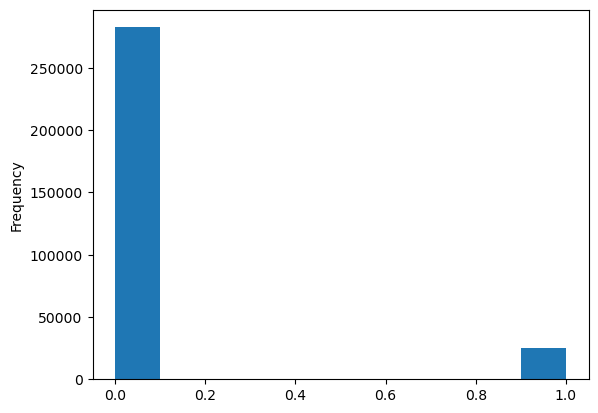

In [8]:
app_train['TARGET'].astype(int).plot.hist();

À partir de ces informations, nous constatons qu’il s’agit d’un problème de classes déséquilibrées.  
Il y a beaucoup plus de prêts qui ont été remboursés à temps que de prêts qui ne l’ont pas été.  
Lorsque nous utiliserons des modèles de machine learning plus sophistiqués, nous pourrons pondérer les classes en fonction de leur représentation dans les données afin de tenir compte de ce déséquilibre.


## Examen des valeurs manquantes

In [9]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [10]:
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


Lorsque viendra le moment de construire nos modèles de machine learning, nous devrons remplir ces valeurs manquantes (ce qu’on appelle l’imputation).  
Dans un travail ultérieur, nous utiliserons des modèles comme **XGBoost**, qui peuvent gérer les valeurs manquantes sans nécessiter d’imputation.  
Une autre option serait de supprimer les colonnes présentant un pourcentage élevé de valeurs manquantes, bien qu’il soit impossible de savoir à l’avance si ces colonnes seront utiles à notre modèle.  
Par conséquent, nous allons conserver toutes les colonnes pour le moment.


## Types des colonnes

Regardons le nombre de colonnes pour chaque type de données.  
Les colonnes de type **int64** et **float64** sont des variables numériques (qui peuvent être discrètes ou continues).  
Les colonnes de type **object** contiennent des chaînes de caractères et représentent des variables catégorielles.


In [11]:
app_train.dtypes.value_counts()


float64    65
int64      41
object     16
Name: count, dtype: int64

Regardons maintenant le nombre de valeurs uniques dans chacune des colonnes de type **object** (catégorielles).


In [12]:
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

La plupart des variables catégorielles ont un nombre relativement faible de valeurs uniques.  
Nous devrons trouver une méthode pour gérer ces variables catégorielles !


### Encodage des variables catégorielles

Avant d'aller plus loin, nous devons gérer les variables catégorielles. Malheureusement, un modèle de machine learning ne peut pas traiter directement ces variables (à l'exception de certains modèles comme LightGBM). Nous devons donc trouver un moyen d'encoder (représenter) ces variables sous forme de nombres avant de les passer au modèle.  

Il existe deux méthodes principales pour cela :

- **Encodage par étiquettes (Label encoding)** : on assigne à chaque catégorie unique d'une variable catégorielle un entier. Aucune nouvelle colonne n'est créée. Voici un exemple ci-dessous.

- **Encodage one-hot (One-hot encoding)** : on crée une nouvelle colonne pour chaque catégorie unique d'une variable catégorielle. Chaque observation reçoit un 1 dans la colonne correspondant à sa catégorie, et un 0 dans toutes les autres nouvelles co

L'encodage par étiquettes (label encoding) pose problème car il attribue un ordre arbitraire aux catégories, ce qui peut induire en erreur le modèle qui interprète ces valeurs numériques comme ayant un sens relatif. Par exemple, si « programmeur » reçoit la valeur 4 et « data scientist » la valeur 1, cet ordre n’a aucun sens réel et pourrait changer si l’encodage est refait. Cela fonctionne bien uniquement pour les variables catégorielles à deux modalités (ex : Homme/Femme).

Pour plus de deux catégories, l’encodage one-hot est plus sûr car il crée une colonne binaire pour chaque catégorie sans imposer d’ordre, mais cela peut augmenter fortement le nombre de dimensions. Pour limiter cet effet, on peut combiner l’encodage one-hot avec une réduction de dimension (comme la PCA).

Dans ce projet, on utilisera l’encodage par étiquettes pour les variables à deux catégories et l’encodage one-hot pour celles en ayant plus de deux, sans réduction de dimension pour l’instant. Pour cela, on utilisera `LabelEncoder` de Scikit-Learn et `get_dummies` de pandas.
lonnes.


In [13]:
le = LabelEncoder()
encoders = {}
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        if app_train[col].nunique() <= 2:
            le = LabelEncoder()
            app_train[col] = le.fit_transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            encoders[col] = le
            le_count += 1

print(f"{le_count} columns were label encoded.")

# Sauvegarder tous les encoders
joblib.dump(encoders, "label_encoders.pkl")

4 columns were label encoded.


['label_encoders.pkl']

In [14]:
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 242)
Testing Features shape:  (48744, 238)


### Alignement des données d'entraînement et de test

Il faut que les données d'entraînement et de test aient les mêmes caractéristiques (colonnes). L'encodage one-hot a créé plus de colonnes dans les données d'entraînement parce que certaines variables catégorielles contenaient des catégories absentes des données de test. 

Pour supprimer les colonnes des données d'entraînement qui ne sont pas dans les données de test, il faut aligner les deux DataFrames. 

On commence par extraire la colonne cible (target) des données d'entraînement, car elle n'existe pas dans les données de test mais doit être conservée. Lors de l'alignement, il faut bien définir `axis=1` pour aligner selon les colonnes (et non les lignes).


In [15]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 239)
Testing Features shape:  (48744, 238)


In [16]:
print('Testing Features shape: ', app_test.shape)

Testing Features shape:  (48744, 238)


Les jeux de données d'entraînement et de test ont désormais les mêmes caractéristiques, ce qui est nécessaire pour l'apprentissage automatique. 

Le nombre de caractéristiques a considérablement augmenté à cause de l'encodage one-hot. À un moment donné, il sera probablement nécessaire d'essayer une réduction de dimensionnalité (en supprimant les caractéristiques non pertinentes) afin de réduire la taille des jeux de données.


### Retour à l'analyse exploratoire des données (EDA)

#### Anomalies

Un problème que l'on cherche toujours à détecter lors de l'EDA est la présence d'anomalies dans les données. Celles-ci peuvent être dues à des erreurs de saisie, des défauts d'appareils de mesure, ou bien être des valeurs valides mais extrêmes.

Une façon d'identifier ces anomalies de manière quantitative est d'examiner les statistiques descriptives d'une colonne avec la méthode `describe`.

Les valeurs de la colonne `DAYS_BIRTH` sont négatives car elles sont enregistrées par rapport à la date actuelle de la demande de prêt. Pour afficher ces statistiques en années, on peut multiplier par -1 puis diviser par le nombre de jours dans une année :


In [17]:
(app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [18]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Ça ne semble pas correct ! La valeur maximale (en plus d’être positive) correspond à environ 1000 ans !


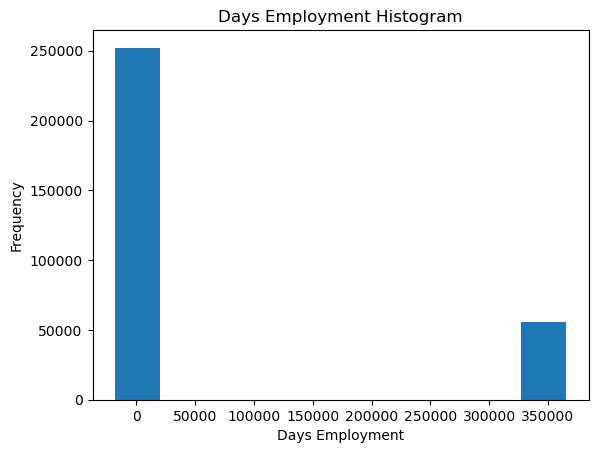

In [19]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

Par simple curiosité, isolons les clients présentant des valeurs anormales et voyons s'ils ont tendance à avoir des taux de défaut plus élevés ou plus faibles que le reste des clients.


In [20]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


Eh bien, c’est extrêmement intéressant ! Il s’avère que les anomalies ont un taux de défaut plus faible.

La gestion des anomalies dépend de la situation exacte, il n’y a pas de règles fixes. L’une des approches les plus sûres consiste simplement à remplacer les anomalies par des valeurs manquantes, puis à les imputer avant l’apprentissage automatique. Dans ce cas, puisque toutes les anomalies ont exactement la même valeur, nous voulons les remplacer par la même valeur au cas où tous ces prêts partageraient quelque chose en commun. 

Les valeurs anormales semblent avoir une certaine importance, donc nous voulons indiquer au modèle d’apprentissage automatique si nous avons effectivement remplacé ces valeurs. 

Comme solution, nous allons remplacer les valeurs anormales par “not a number” (np.nan) puis créer une nouvelle colonne booléenne indiquant si la valeur était anormale ou non.


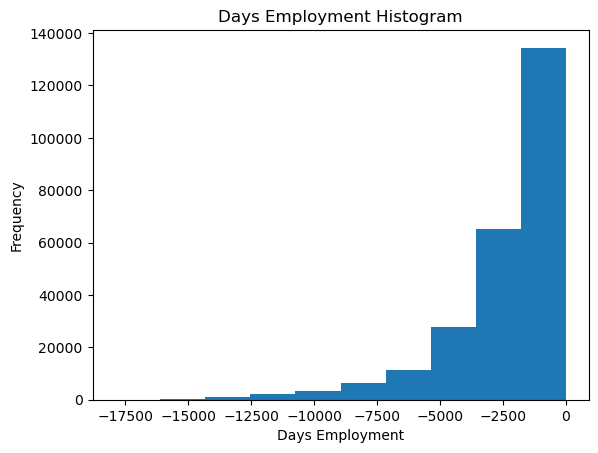

In [21]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

La distribution semble maintenant beaucoup plus conforme à ce que nous attendions, et nous avons également créé une nouvelle colonne pour indiquer au modèle que ces valeurs étaient à l'origine anormales (car nous devrons remplacer les valeurs manquantes par une valeur, probablement la médiane de la colonne). Les autres colonnes contenant « DAYS » dans le dataframe semblent correspondre à ce que nous attendons, sans valeurs aberrantes évidentes.

Note extrêmement importante : tout ce que nous faisons aux données d'entraînement doit également être fait aux données de test. Assurons-nous donc de créer la nouvelle colonne et de remplir la colonne existante avec des `np.nan` dans les données de test.


In [22]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 9274 anomalies in the test data out of 48744 entries


### Corrélations

Maintenant que nous avons traité les variables catégorielles et les valeurs aberrantes, continuons avec l’analyse exploratoire des données (EDA). 

Une façon d’essayer de comprendre les données est de rechercher des corrélations entre les caractéristiques (features) et la cible (target). Nous pouvons calculer le coefficient de corrélation de Pearson entre chaque variable et la cible en utilisant la méthode `.corr` du dataframe.

Le coefficient de corrélation n’est pas la meilleure méthode pour représenter la « pertinence » d’une variable, mais il nous donne une idée des relations possibles dans les données. Voici quelques interprétations générales de la valeur absolue du coefficient de corrélation :

- 0.00 - 0.19 : « très faible »
- 0.20 - 0.39 : « faible »
- 0.40 - 0.59 : « modérée »
- 0.60 - 0.79 : « forte »
- 0.80 - 1.00 : « très forte »


In [23]:
correlations = app_train.corr()['TARGET'].sort_values()

print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

Regardons quelques-unes des corrélations les plus significatives : **DAYS_BIRTH** est la corrélation positive la plus importante (à l’exception de TARGET).

D’après la documentation, **DAYS_BIRTH** correspond à l’âge du client en jours au moment du prêt, exprimé en nombre négatif de jours (pour une raison inconnue !). La corrélation est positive, mais la valeur de cette variable est en fait négative, ce qui signifie que plus le client est âgé, moins il a de chances de faire défaut sur son prêt (c’est-à-dire que TARGET == 0).

Cela peut prêter à confusion, donc nous allons prendre la valeur absolue de cette variable, ce qui fera que la corrélation deviendra négative.


### Effet de l'age sur le payment

In [24]:
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

-0.07823930830982712

Au fur et à mesure que le client vieillit, il existe une relation linéaire négative avec la cible, ce qui signifie qu’à mesure que les clients vieillissent, ils ont tendance à rembourser leurs prêts à temps plus souvent.

Commençons par examiner cette variable. Tout d’abord, nous pouvons tracer un histogramme de l’âge. Nous mettrons l’axe des x en années pour rendre le graphique un peu plus compréhensible.


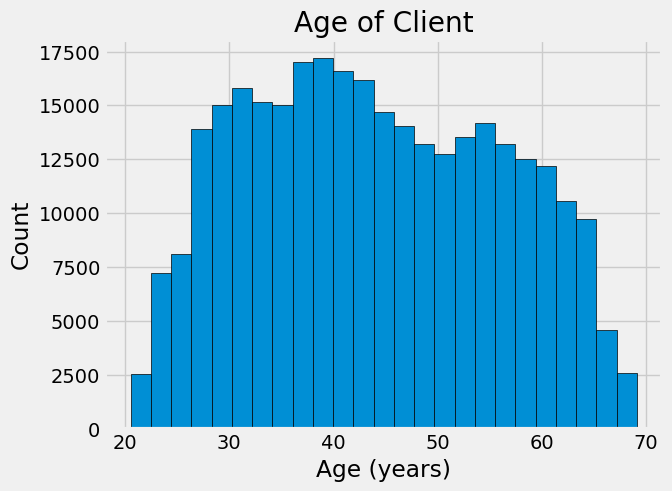

In [25]:
plt.style.use('fivethirtyeight')

plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

À elle seule, la distribution de l’âge ne nous apprend pas grand-chose, si ce n’est qu’il n’y a pas de valeurs aberrantes puisque tous les âges sont raisonnables. 

Pour visualiser l’effet de l’âge sur la cible, nous allons ensuite réaliser un graphique d’estimation de densité par noyau (KDE) coloré selon la valeur de la cible. 

Un graphique KDE montre la distribution d’une variable unique et peut être vu comme un histogramme lissé (il est créé en calculant un noyau, généralement gaussien, à chaque point de données, puis en faisant la moyenne de tous ces noyaux individuels pour obtenir une courbe lisse unique).

Nous utiliserons la fonction `kdeplot` de la bibliothèque seaborn pour ce graphique.


C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


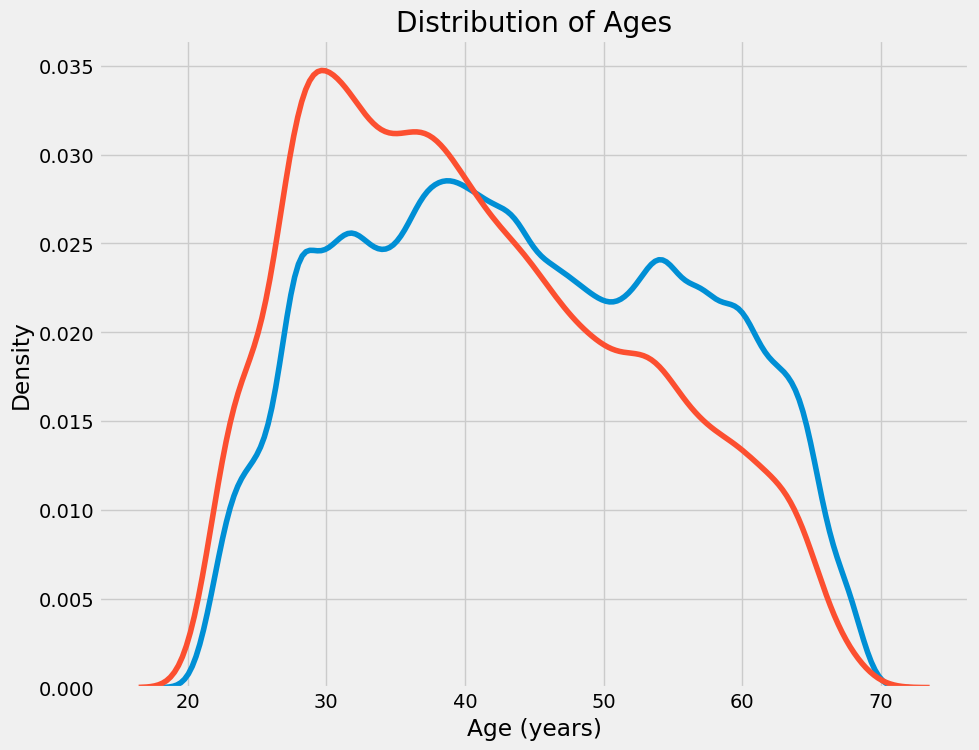

In [26]:
plt.figure(figsize = (10, 8))

sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

La courbe pour `target == 1` est davantage concentrée vers les âges les plus jeunes. Bien que la corrélation soit faible (-0,07 coefficient de corrélation), cette variable sera probablement utile dans un modèle de machine learning car elle influence la cible.

Voyons cette relation d’une autre manière : la moyenne des défauts de remboursement par tranche d’âge.

Pour réaliser ce graphique, nous découpons d’abord la variable âge en intervalles de 5 ans. Puis, pour chaque intervalle, nous calculons la moyenne de la cible, ce qui nous donne le taux de prêts non remboursés dans chaque tranche d’âge.


In [27]:
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

C:\Users\Rafael\AppData\Local\Temp\ipykernel_23440\4015444297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365
C:\Users\Rafael\AppData\Local\Temp\ipykernel_23440\4015444297.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))


,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [28]:
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

C:\Users\Rafael\AppData\Local\Temp\ipykernel_23440\3685359187.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups  = age_data.groupby('YEARS_BINNED').mean()


,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


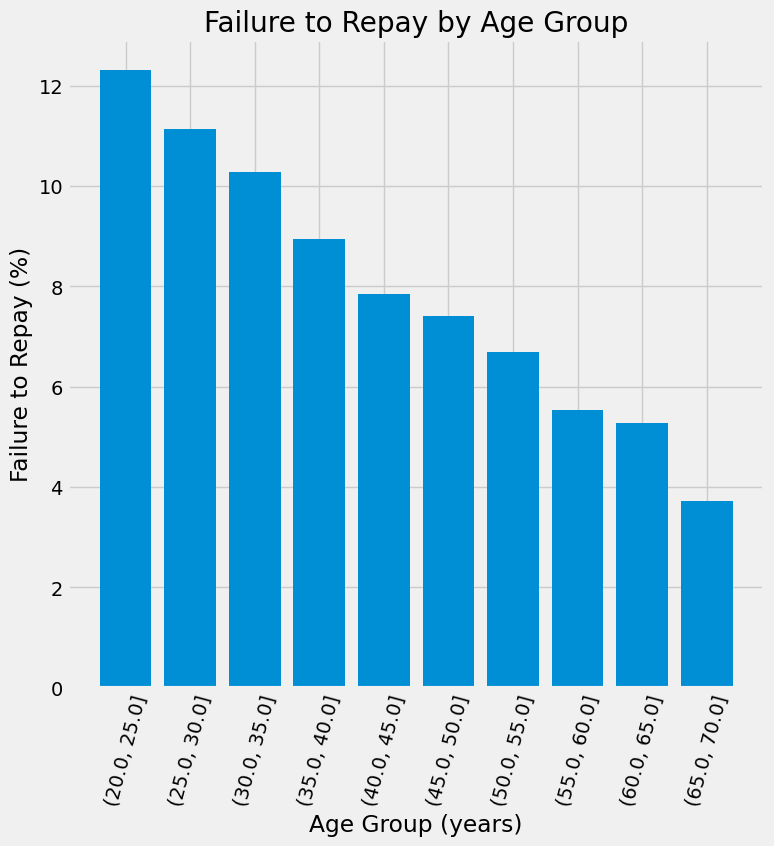

In [29]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group');

Il existe une tendance claire : les emprunteurs plus jeunes ont plus de chances de ne pas rembourser leur prêt ! Le taux de défaut de paiement est supérieur à 10 % pour les trois groupes d'âge les plus jeunes, et inférieur à 5 % pour le groupe d'âge le plus âgé.

C’est une information qui pourrait être directement utilisée par la banque : puisque les jeunes clients ont moins de chances de rembourser leur prêt, il serait peut-être judicieux de leur fournir plus de conseils ou d’aide en gestion financière. Cela ne signifie pas que la banque doit discriminer les jeunes clients, mais il serait intelligent de prendre des mesures préventives pour les aider à payer à temps.

### Sources externes  
Les 3 variables qui ont la corrélation négative la plus forte avec la cible sont EXT_SOURCE_1, EXT_SOURCE_2 et EXT_SOURCE_3. Selon la documentation, ces variables représentent un « score normalisé provenant de sources de données externes ». Je ne suis pas certain de ce que cela signifie exactement, mais il pourrait s’agir d’une sorte de notation de crédit cumulative basée sur plusieurs sources de données.

Regardons ces variables de plus près.

Premièrement, nous pouvons afficher les corrélations des variables EXT_SOURCE avec la cible et entre elles.


In [30]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


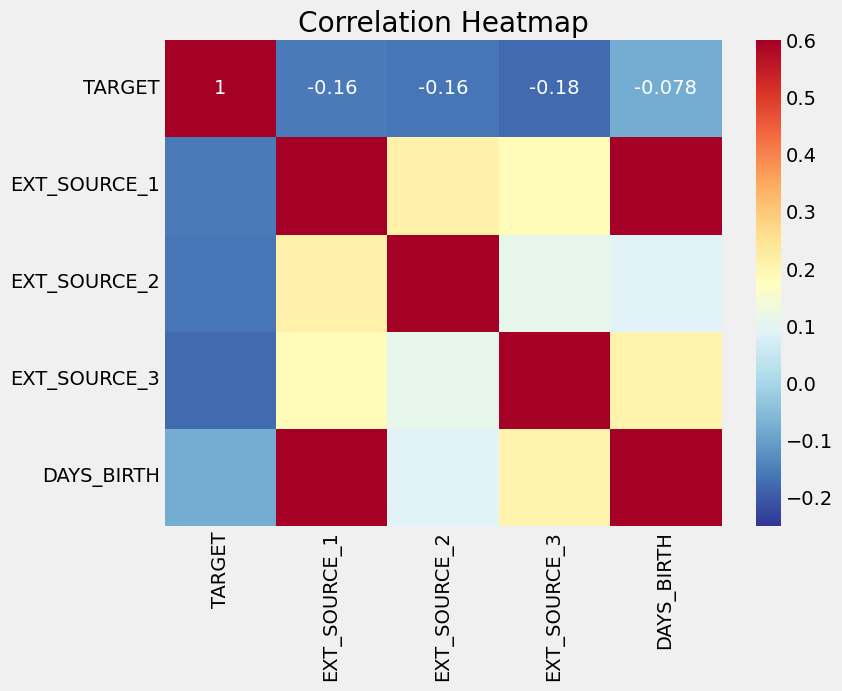

In [31]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

Les trois variables EXT_SOURCE présentent une corrélation négative avec la cible, ce qui indique que plus la valeur d’EXT_SOURCE est élevée, plus le client est susceptible de rembourser son prêt. On observe également que DAYS_BIRTH est positivement corrélé avec EXT_SOURCE_1, ce qui suggère qu’un des facteurs pris en compte dans ce score pourrait être l’âge du client.

Nous pouvons ensuite examiner la distribution de chacune de ces variables, colorée selon la valeur de la cible. Cela nous permettra de visualiser l’effet de ces variables sur la cible.


C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

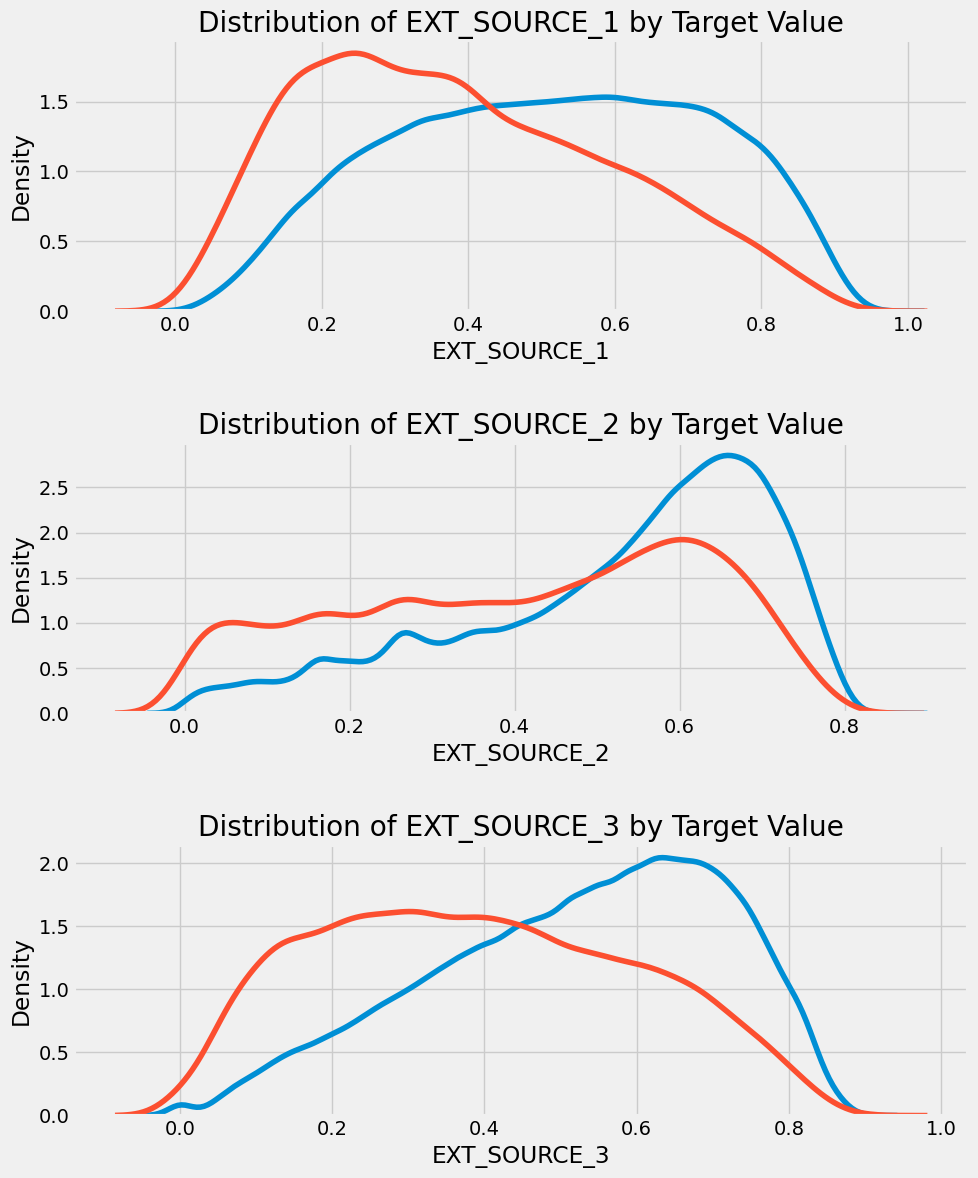

In [31]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

EXT_SOURCE_3 montre la plus grande différence entre les valeurs selon la cible. On peut clairement voir que cette variable est liée à la probabilité qu’un demandeur rembourse son prêt. La relation n’est pas très forte (en réalité, toutes ces corrélations sont faibles), mais ces variables resteront utiles pour un modèle de machine learning afin de prédire si un emprunteur remboursera son prêt à temps ou non.

### Diagramme de paires (Pairs Plot)  
Pour finir cette exploration, nous pouvons réaliser un diagramme de paires des variables EXT_SOURCE et de la variable DAYS_BIRTH. Le diagramme de paires est un excellent outil d’exploration car il permet de visualiser les relations entre plusieurs couples de variables ainsi que la distribution de chaque variable individuellement.

Ici, nous utilisons la bibliothèque seaborn et la fonction PairGrid pour créer un diagramme avec des nuages de points dans le triangle supérieur, des histogrammes sur la diagonale, et des courbes de densité 2D ainsi que des coefficients de corrélation dans le triangle inférieur.

Si vous ne comprenez pas ce code, ne vous inquiétez pas ! La visualisation en Python peut être complexe, et pour tout ce qui dépasse les graphiques simples, je préfère souvent adapter un code existant (ne vous répétez pas !).


C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

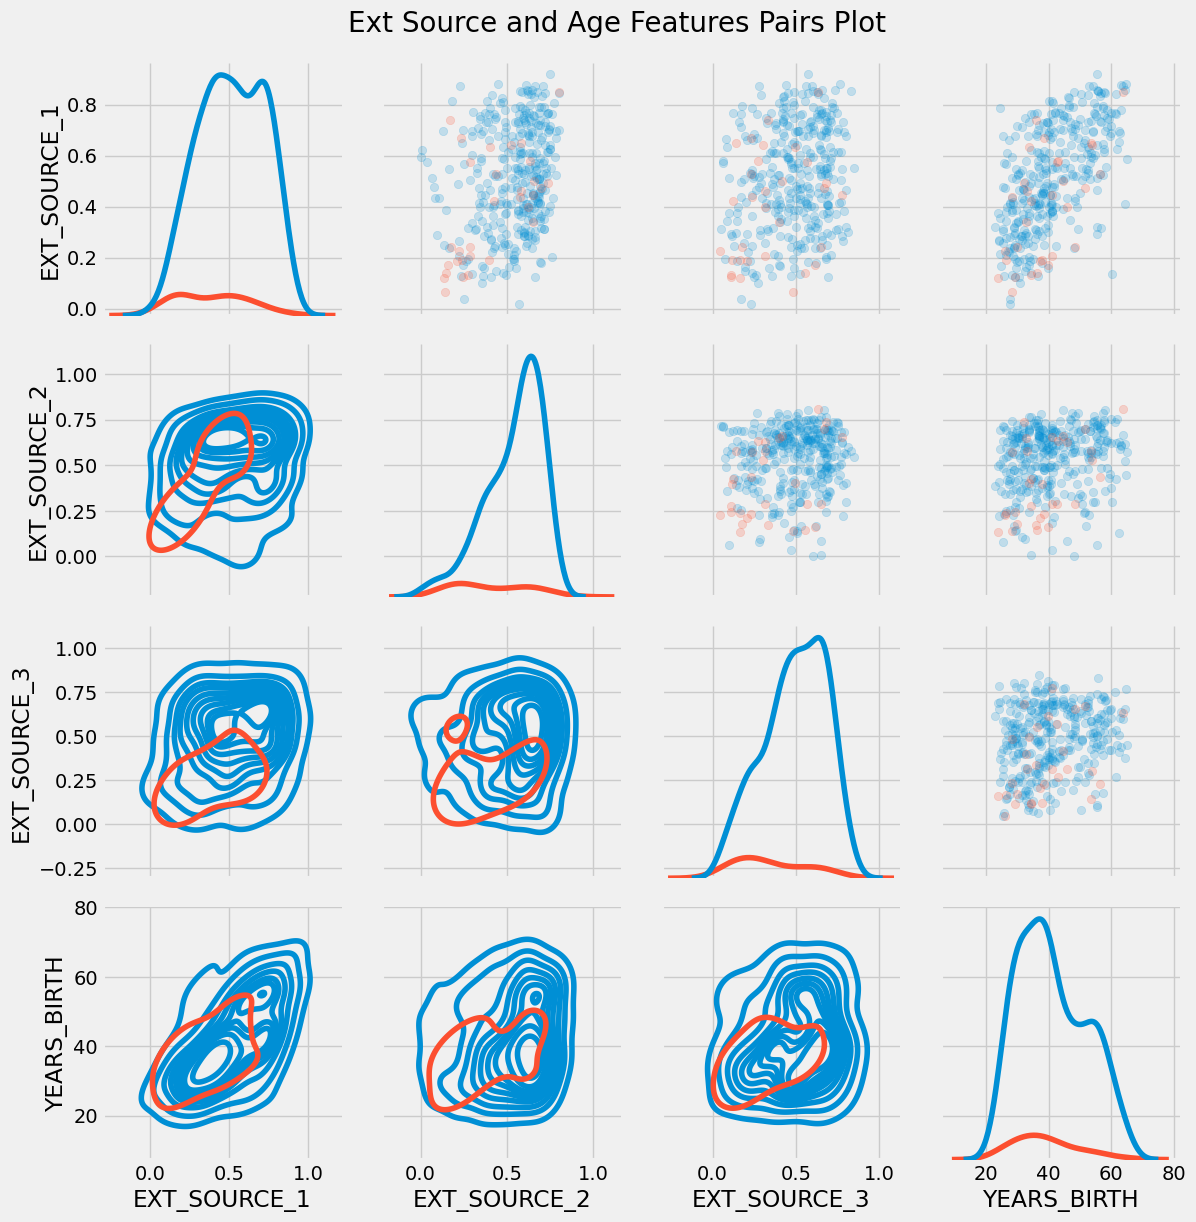

In [32]:
# Copy the data for plotting
plot_data = ext_data.drop(columns=['DAYS_BIRTH']).copy().sample(1000)

# Add in the age of the client in years
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Drop na values and limit to first 100000 rows
plot_data = plot_data.dropna().iloc[:100000, :]

# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}",
                xy=(.2, .8), xycoords=ax.transAxes,
                size=14)

# Create the pairgrid object with corrected parameter 'height' instead of 'size'
grid = sns.PairGrid(data=plot_data, height=3, diag_sharey=False,
                    hue='TARGET',
                    vars=[col for col in plot_data.columns if col != 'TARGET'])

# Upper is a scatter plot
grid.map_upper(plt.scatter, alpha=0.2)

# Diagonal is a KDE plot
grid.map_diag(sns.kdeplot)

# Bottom is a KDE plot with a color map
grid.map_lower(sns.kdeplot, cmap=plt.cm.OrRd_r)

plt.suptitle('Ext Source and Age Features Pairs Plot', size=20, y=1.02)
plt.show()

## Verifier le data leakage

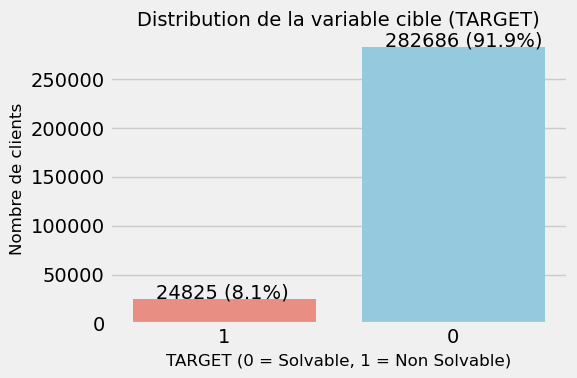

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir en string pour éviter le problème avec la palette
app_train['TARGET_STR'] = app_train['TARGET'].astype(str)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET_STR', data=app_train, palette={'0': 'skyblue', '1': 'salmon'})

# Ajout des annotations
total = len(app_train)
for p in plt.gca().patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    plt.gca().annotate(f'{count} ({percentage:.1f}%)', (p.get_x() + 0.1, p.get_height() + 500))

# Titres
plt.title("Distribution de la variable cible (TARGET)", fontsize=14)
plt.xlabel("TARGET (0 = Solvable, 1 = Non Solvable)", fontsize=12)
plt.ylabel("Nombre de clients", fontsize=12)
plt.tight_layout()
plt.show()


## Verifier le data leakage (refactor complet)

Objectifs :
1. **Aucun data leakage** : imputation / scaling / **SMOTE uniquement sur le train** via un `Pipeline` imblearn.
2. **Features polynomiales** limitées à `EXT_SOURCE_1/2/3` et `DAYS_BIRTH` (si présentes) **dans le pipeline** (pas en amont).
3. **Comparaison multi‑modèles** (LogReg, RandomForest, GradientBoosting) **avec et sans polynômes** sur un **même split train/test**.
4. **Noms clairs** : `X_train`, `X_test`, `y_train`, `y_test`. Aucune variable ambiguë type `app_train_resampled`.




In [33]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Séparer features et target
X = app_train.drop(columns=['TARGET', 'TARGET_STR'])
y = app_train['TARGET']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Imputation des NaN par la médiane
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

# Reconstruction du DataFrame
app_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
app_train_resampled['TARGET'] = y_train_resampled.values

# Résultat
print("Nouvelle forme :", app_train_resampled.shape)
print(app_train_resampled['TARGET'].value_counts())

Nouvelle forme : (395760, 240)
TARGET
0    197880
1    197880
Name: count, dtype: int64


Dans ce graphique, le rouge indique les prêts qui n'ont pas été remboursés et le bleu ceux qui ont été remboursés. On peut observer différentes relations dans les données. Il semble y avoir une relation linéaire positive modérée entre EXT_SOURCE_1 et DAYS_BIRTH (ou équivalent YEARS_BIRTH), ce qui indique que cette variable pourrait prendre en compte l’âge du client.

## Feature Engineering  
Les compétitions Kaggle se gagnent grâce au feature engineering : ceux qui gagnent sont ceux qui parviennent à créer les caractéristiques les plus utiles à partir des données. (C’est généralement vrai puisque les modèles gagnants, au moins pour les données structurées, sont souvent des variantes de gradient boosting). Cela illustre un principe en machine learning : le feature engineering offre un meilleur retour sur investissement que la construction du modèle ou l’optimisation des hyperparamètres. Un excellent article traite de ce sujet. Comme le dit souvent Andrew Ng : « l’apprentissage automatique appliqué, c’est essentiellement du feature engineering ».

Même si choisir le bon modèle et ses paramètres optimaux est important, le modèle ne peut apprendre que sur la base des données qu’on lui fournit. Le travail du data scientist (et parfois des outils automatiques) est de faire en sorte que ces données soient les plus pertinentes pos 
-"garbage in garbage out"sible.

Le feature engineering est un processus général qui peut inclure à la fois la **construction** de nouvelles caractéristiques à partir des données existantes, et la **sélection** des caractéristiques les plus importantes ou d’autres méthodes de réduction de dimensionnalité. Il existe de nombreuses techniques pour créer et sélectionner des caractéristiques.

Nous ferons beaucoup de feature engineering lorsque nous utiliserons les autres sources de données, mais dans ce notebook, nous allons essayer seulement deux méthodes simples de construction de caractéristiques :

- Les features polynomiales  
- Les features basées sur la connaissance métier

### Features polynomiales  
Une méthode simple de construction de caractéristiques s’appelle les features polynomiales. Elle consiste à créer des features qui sont des puissances des variables existantes ainsi que des termes d’interaction entre ces variables. Par exemple, on peut créer des variables EXT_SOURCE_1², EXT_SOURCE_2², mais aussi des variables telles que EXT_SOURCE_1 × EXT_SOURCE_2, EXT_SOURCE_1 × EXT_SOURCE_2², EXT_SOURCE_1² × EXT_SOURCE_2², etc. Ces nouvelles variables, combinant plusieurs variables originales, sont appelées termes d’interaction car elles capturent les interactions entre variables. En d’autres termes, alors que deux variables seules peuvent avoir peu d’influence sur la cible, leur combinaison en une seule variable d’interaction peut révéler une relation avec la cible.

Les termes d’interaction sont souvent utilisés dans les modèles statistiques pour capturer les effets combinés de plusieurs variables, même s’ils sont moins couramment utilisés en machine learning. Néanmoins, nous pouvons en tester quelques-uns pour voir s’ils aident notre modèle à prédire si un client remboitent approfondir.

Dans le code suivant, nous créons des features polynomiales à partir des variables EXT_SOURCE et de la variable DAYS_BIRTH. Scikit-Learn propose une classe utile, `PolynomialFeatures`, qui génère automatiquement ces polynômes et termes d’interaction jusqu’à un degré spécifié. Nous utiliserons un degré 3 pour voir les résultats (il faut éviter de choisir un degré trop élevé car le nombre de features augmente exponentiellement et cela peut entraîner du surapprentissage).


In [34]:
# Sélection des colonnes d'intérêt
poly_features = app_train_resampled[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = X_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# Import de SimpleImputer pour gérer les valeurs manquantes
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

# Séparation de la cible
poly_target = poly_features['TARGET']
poly_features = poly_features.drop(columns=['TARGET'])

# Imputation des valeurs manquantes
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

# Import et création des features polynomiales
from sklearn.preprocessing import PolynomialFeatures
poly_transformer = PolynomialFeatures(degree=3)

# Transformation polynomiale des données
poly_features_poly = poly_transformer.fit_transform(poly_features)
poly_features_test_poly = poly_transformer.transform(poly_features_test)


In [35]:
poly_transformer.fit(poly_features)

poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (395760, 35)


Cela crée un nombre considérable de nouvelles caractéristiques (features).  
Pour obtenir les noms de ces nouvelles caractéristiques, nous devons utiliser la méthode `get_feature_names` de l'objet `PolynomialFeatures`.


In [36]:
poly_transformer.get_feature_names_out(input_features=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])[:15]


array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

There are 35 features with individual features raised to powers up to degree 3 and interaction terms. Now, we can see whether any of these new features are correlated with the target.
METTRE EN FR



In [37]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Add in the target
poly_features['TARGET'] = y_train

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3^2              -0.001476
EXT_SOURCE_3^3                           -0.001342
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.001101
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.000942
EXT_SOURCE_1 EXT_SOURCE_3^2              -0.000744
EXT_SOURCE_2 EXT_SOURCE_3                -0.000741
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.000628
EXT_SOURCE_3^2                           -0.000474
EXT_SOURCE_3^2 DAYS_BIRTH                -0.000345
EXT_SOURCE_1 EXT_SOURCE_2                -0.000100
Name: TARGET, dtype: float64
EXT_SOURCE_1^2 DAYS_BIRTH    0.001512
DAYS_BIRTH                   0.001554
EXT_SOURCE_1^3               0.001982
TARGET                       1.000000
1                                 NaN
Name: TARGET, dtype: float64


Plusieurs des nouvelles variables présentent une corrélation plus forte (en valeur absolue) avec la cible que les caractéristiques originales. Lors de la construction de modèles de machine learning, nous pouvons tester avec et sans ces nouvelles variables pour déterminer si elles aident réellement le modèle à mieux apprendre.

Nous allons ajouter ces nouvelles variables à une copie des données d'entraînement et de test, puis évaluer les modèles avec et sans ces variables. Souvent, en machine learning, la seule façon de savoir si une approche fonctionne est de l'expérimenter !


In [38]:
poly_features['EXT_SOURCE_1']

0         0.675243
1         0.505289
2         0.358038
3         0.385576
4         0.737632
            ...   
395755    0.652597
395756    0.228853
395757    0.313322
395758    0.505289
395759    0.379725
Name: EXT_SOURCE_1, Length: 395760, dtype: float64

In [39]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = app_train_resampled['SK_ID_CURR']
app_train_poly = app_train_resampled.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = X_test['SK_ID_CURR']
app_test_poly = X_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', app_train_poly.shape)
print('Testing data with polynomial features shape:  ', app_test_poly.shape)

Training data with polynomial features shape:  (395760, 274)
Testing data with polynomial features shape:   (92254, 274)


### Features basées sur la connaissance du domaine

Peut-être que ce n'est pas tout à fait correct d'appeler ça "connaissance du domaine", car je ne suis pas un expert du crédit, mais on pourrait plutôt appeler cela des "tentatives d'application d'une connaissance financière limitée". 

Dans cet esprit, nous pouvons créer quelques variables qui cherchent à capturer ce que nous pensons important pour prédire si un client fera défaut sur un prêt. Voici cinq features inspirées par ce script d'Aguiar :

- **CREDIT_INCOME_PERCENT** : le pourcentage du montant du crédit par rapport au revenu du client  
- **ANNUITY_INCOME_PERCENT** : le pourcentage de l'annuité du prêt par rapport au revenu du client  
- **CREDIT_TERM** : la durée du remboursement en mois (puisque l'annuité est le montant mensuel dû)  
- **DAYS_EMPLOYED_PERCENT** : le pourcentage de jours travaillés par rapport à l'âge du client  

Un grand merci à Aguiar et son excellent script pour l'exploration de ces features.


In [40]:
app_train_domain = app_train_resampled.copy()
app_test_domain = X_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

In [41]:
app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

In [42]:
joblib.dump(app_train_domain.drop(columns='TARGET').columns, "feature_columns.pkl")

['feature_columns.pkl']

### Visualiser les nouvelles variables

Nous devrions explorer visuellement ces variables basées sur la connaissance du domaine à l’aide de graphiques. Pour chacune d’elles, nous allons créer un graphique KDE (estimation de densité) coloré selon la valeur de la variable TARGET.


C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Rafael\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

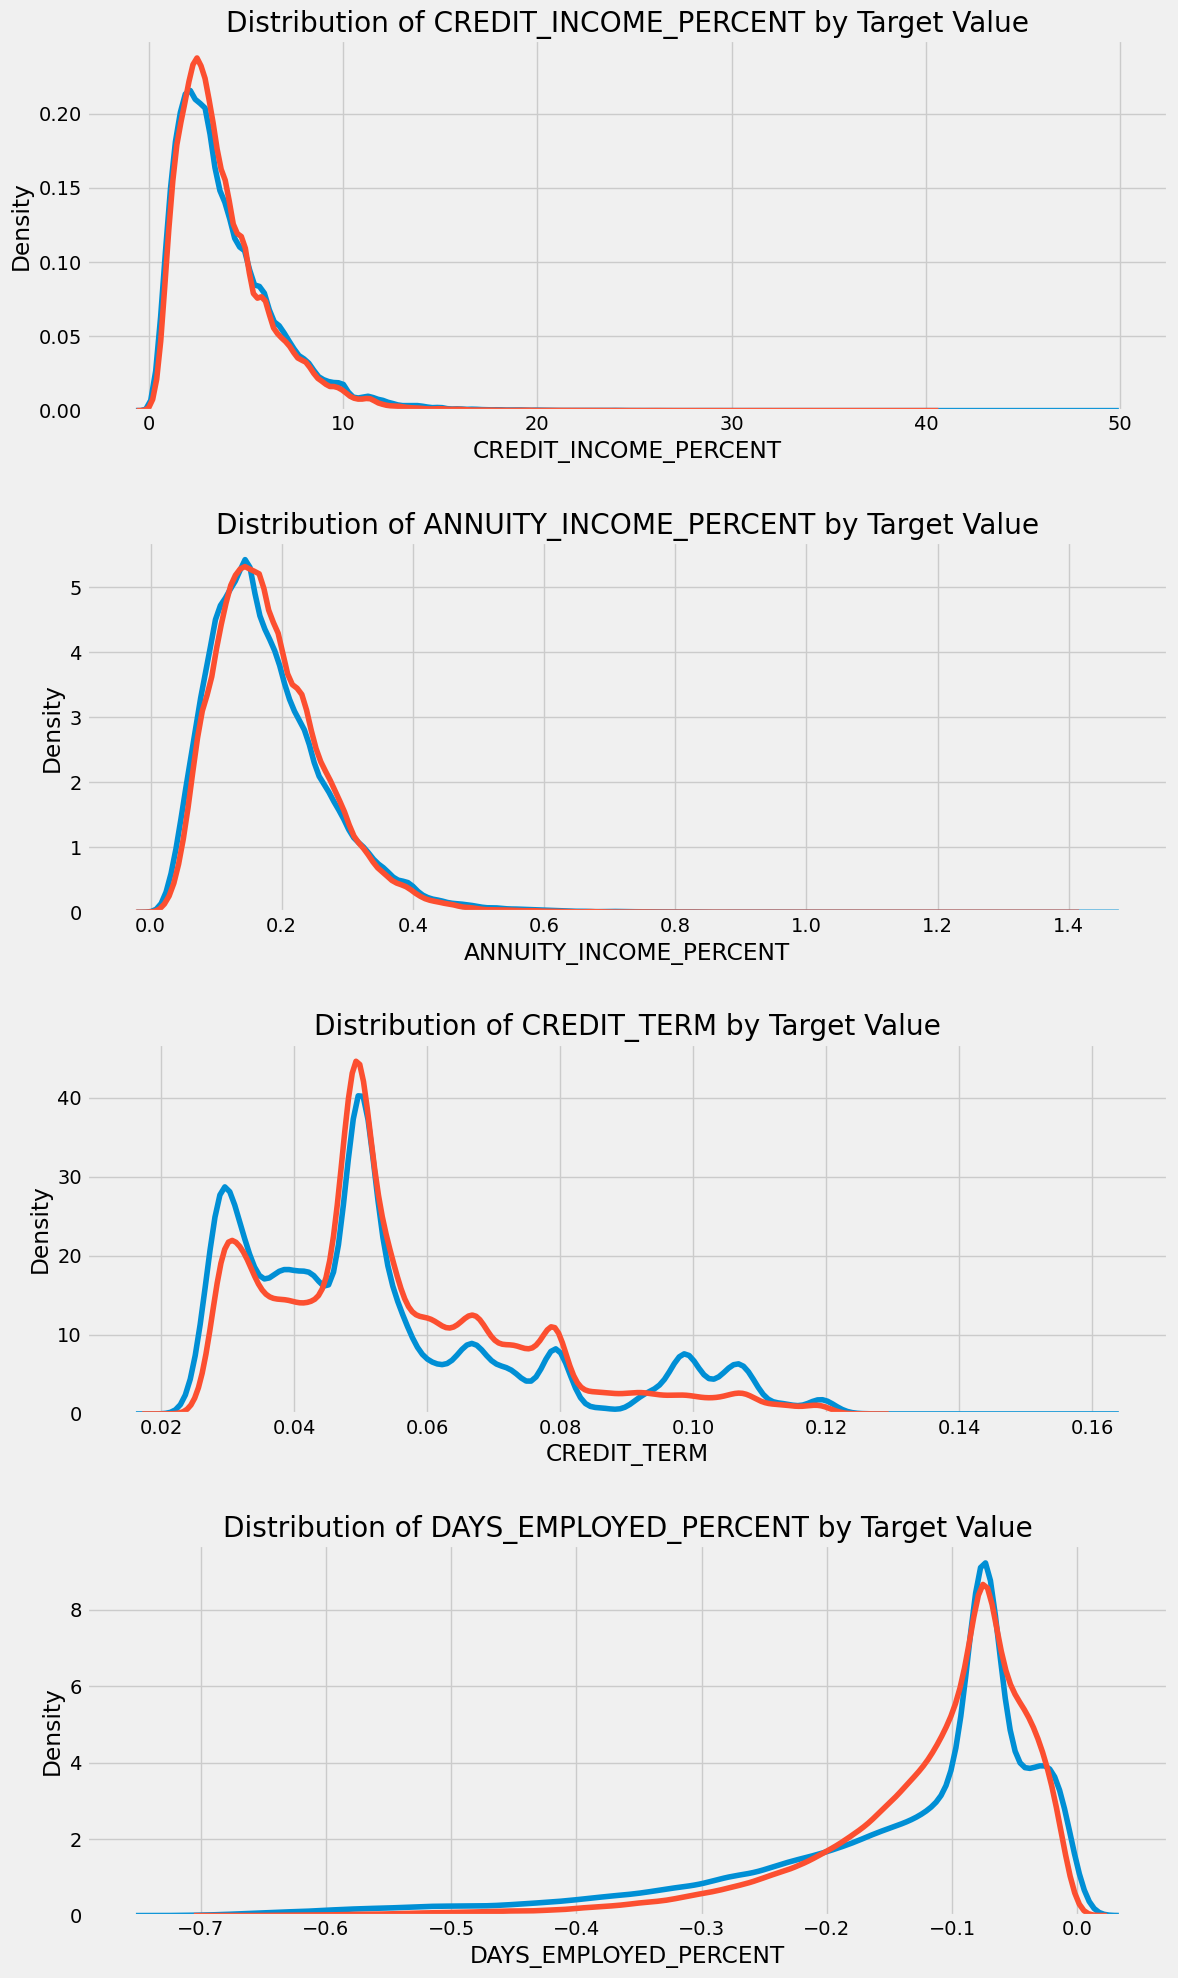

In [43]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

Il est difficile de dire à l'avance si ces nouvelles variables seront utiles. La seule façon d'en être sûr est de les tester !


## Sauvegarde des dataset final

app_train_domain
app_test_domain

# Baseline

Pour une baseline naïve, on pourrait deviner la même valeur pour tous les exemples du jeu de test. On nous demande de prédire la probabilité de non-remboursement du prêt, donc si nous sommes totalement incertains, on devinerait 0,5 pour toutes les observations du jeu de test. Cela nous donnerait un score AUC ROC (Receiver Operating Characteristic Area Under the Curve) de 0,5 dans la compétition (un tirage aléatoire dans une tâche de classification obtient un score de 0,5).

Puisque nous savons déjà quel score nous allons obtenir, nous n'avons pas vraiment besoin de faire une prédiction naïve. Utilisons un modèle un peu plus sophistiqué pour notre baseline réelle : la régression logistique.

## Implémentation de la Régression Logistique

Ici, je vais me concentrer sur l’implémentation du modèle plutôt que d’expliquer les détails, mais pour ceux qui souhaitent en savoir plus sur la théorie des algorithmes de machine learning, je recommande **An Introduction to Statistical Learning** et **Hands-On Machine Learning with Scikit-Learn and TensorFlow**. Ces deux livres présentent à la fois la théorie et le code nécessaire pour construire les modèles (en R et Python respectivement). Ils enseignent avec l’idée que la meilleure façon d’apprendre est de pratiquer, et ils sont très efficaces !

Pour obtenir une baseline, nous utiliserons toutes les variables après encodage des variables catégoriques. Nous allons prétraiter les données en remplissant les valeurs manquantes (imputation) et en normalisant la plage des variables (mise à l’échelle des features). Le code suivant réalise ces deux étapes de prétraitement.


Definir notre score metier perso

regarder pour sklearn pour ajouter une loss perso

La fonction doit prendre en parametre le nb de faux positif et faux negatif

Elle retourne une ponderation de mes faux positifs / negatifs

exemple (voir la fonction de churn)
https://www.kaggle.com/code/alperengin/custom-scoring-using-scikit-learn-make-scorer#Custom-metric-for-churn

In [46]:
from sklearn.metrics import confusion_matrix, make_scorer

def custom_business_score(y_true, y_pred, cost_fp=5, cost_fn=1):
    """   
    - y_true : vraies étiquettes
    - y_pred : prédictions binaires
    - cost_fp : coût d'un faux positif
    - cost_fn : coût d'un faux négatif
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = (fp * cost_fp) + (fn * cost_fn)
    
    return -total_cost  # On retourne le négatif pour que "plus c'est grand, mieux c'est"

business_scorer = make_scorer(custom_business_score, greater_is_better=True)


In [47]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

In [48]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# Drop the target from the training data
train_labels = app_train_resampled['TARGET']
if 'TARGET' in app_train_resampled:
    train = app_train_resampled.drop(columns=['TARGET'])
else:
    train = app_train_resampled.copy()

# Feature names
features = list(train.columns)

# Copy of the testing data
test = app_test.copy()

# Median imputation of missing values
imputer = SimpleImputer(strategy='median')

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit imputer on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)
test = imputer.transform(test)

# Fit scaler on the training data
scaler.fit(train)

# Transform both training and testing data
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)


Training data shape:  (395760, 239)
Testing data shape:  (48744, 239)


## Régression Logistique

Nous allons utiliser la classe `LogisticRegression` de Scikit-Learn pour notre premier modèle. Le seul changement que nous allons apporter par rapport aux paramètres par défaut est de diminuer le paramètre de régularisation `C`, qui contrôle la quantité de sur-apprentissage (une valeur plus faible devrait réduire le sur-apprentissage). Cela nous donnera des résultats légèrement meilleurs que le modèle `LogisticRegression` par défaut, mais cela reste une baseline modeste pour les modèles futurs.

Ici, nous utilisons la syntaxe familière de Scikit-Learn pour le modeling : d'abord, nous créons le modèle, puis nous l'entraînons avec la méthode `.fit`, puis nous faisons des prédictions sur les données de test avec `.predict_proba` (rappelons que nous voulons des probabilités, pas des valeurs 0 ou 1).


In [49]:
from sklearn.linear_model import LogisticRegression


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Exemple simple avec LogisticRegression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(LogisticRegression(), param_grid, scoring='recall', cv=5)
grid.fit(train, train_labels)



C:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1]}, scoring='recall')

In [51]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# accuracy_score( )
preds = grid.best_estimator_.predict(train)
accuracy_score(train_labels, preds)
recall_score(train_labels, preds )
precision_score(train_labels, preds )

0.6990309652463462

0.4840989399293286 before SMOTE data leakage handling

## Prédictions avec le modèle entraîné

Maintenant que le modèle a été entraîné, nous pouvons l'utiliser pour faire des prédictions. Nous souhaitons prédire les probabilités de non-remboursement d’un prêt, donc nous utilisons la méthode `predict_proba` du modèle. 

Cette méthode renvoie un tableau de taille *m x 2*, où *m* est le nombre d’observations. La première colonne correspond à la probabilité que la cible soit 0 (prêt remboursé), et la deuxième colonne correspond à la probabilité que la cible soit 1 (prêt non remboursé). Pour chaque ligne, la somme des deux colonnes est égale à 1.

Comme nous voulons la probabilité que le prêt ne soit pas remboursé, nous allons sélectionner la deuxième colonne.

Le code suivant effectue les prédictions et récupère la colonne correspondante.


In [52]:
log_reg_pred = grid.predict_proba(test)[:, 1]


Les prédictions doivent être au format indiqué dans le fichier `sample_submission.csv`, qui ne contient que deux colonnes : `SK_ID_CURR` et `TARGET`.  
Nous allons créer un dataframe dans ce format à partir du jeu de test et des prédictions, que nous appellerons `submit`.


In [53]:
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()

C:\Users\Rafael\AppData\Local\Temp\ipykernel_23440\3970473317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['TARGET'] = log_reg_pred


,SK_ID_CURR,TARGET
0,100001,0.383605
1,100005,0.809354
2,100013,0.225820
3,100028,0.360791
4,100038,0.674949


Les prédictions représentent une probabilité entre 0 et 1 que le prêt ne soit pas remboursé.  
Si nous utilisions ces prédictions pour classer les demandeurs, nous pourrions définir un seuil de probabilité au-delà duquel un prêt serait considéré comme risqué.


In [54]:
submit.to_csv('log_reg_baseline.csv', index = False)


La soumission a maintenant été sauvegardée dans l’environnement virtuel où tourne notre notebook.  
Pour accéder à la soumission, à la fin du notebook, il suffit de cliquer sur le bouton bleu **Commit & Run** en haut à droite du kernel. Cela lance l’exécution complète du notebook puis permet de télécharger les fichiers créés pendant l’exécution.

Une fois le notebook exécuté, les fichiers générés sont disponibles dans l’onglet **Versions**, sous-onglet **Output**. De là, les fichiers de soumission peuvent être envoyés à la compétition ou téléchargés.  
Comme plusieurs modèles sont utilisés dans ce notebook, il y aura plusieurs fichiers de sortie.

Le modèle de base avec régression logistique devrait obtenir un score d’environ 0.671 lors de la soumission.

### Modèle amélioré : Forêt aléatoire (Random Forest)

Pour essayer de dépasser la faible performance de notre modèle de base, nous pouvons changer d’algorithme.  
Essayons d’utiliser une forêt aléatoire avec les mêmes données d’entraînement pour voir comment cela impacte la performance.  
La forêt aléatoire est un modèle beaucoup plus puissant, surtout quand on utilise des centaines d’arbres.  
Ici, nous allons utiliser 100 arbres dans la forêt aléatoire.


In [55]:
from sklearn.ensemble import RandomForestClassifier


In [56]:
from sklearn.ensemble import RandomForestClassifier

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

In [57]:
# Train on the training data
random_forest.fit(train, train_labels)

# Extract feature importances
feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

# Make predictions on the test data
predictions = random_forest.predict_proba(test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   46.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished


In [58]:
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline.csv', index = False)

C:\Users\Rafael\AppData\Local\Temp\ipykernel_23440\2349398329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['TARGET'] = predictions


In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

# Noms des features polynomiales
poly_features_names = list(app_train_poly.columns)

# Imputer pour gérer les valeurs manquantes
imputer = SimpleImputer(strategy='median')

poly_features = imputer.fit_transform(app_train_poly)
poly_features_test = imputer.transform(app_test_poly)

# Normalisation des features polynomiales
scaler = MinMaxScaler(feature_range=(0, 1))

poly_features = scaler.fit_transform(poly_features)
poly_features_test = scaler.transform(poly_features_test)

# Modèle Random Forest
random_forest_poly = RandomForestClassifier(n_estimators=100, random_state=50, verbose=1, n_jobs=-1)


Ces prédictions seront également disponibles lorsque nous exécuterons l’intégralité du notebook.

Ce modèle devrait obtenir un score d’environ 0,678 lors de la soumission.

### Faire des prédictions avec les features créées

La seule façon de savoir si les features polynomiales et la connaissance métier (domain knowledge) ont amélioré le modèle est d’entraîner et tester un modèle sur ces nouvelles features !  
Nous pourrons ensuite comparer la performance obtenue lors de la soumission avec celle du modèle sans ces features pour évaluer l’impact de notre ingénierie des features.


In [60]:
random_forest_poly.fit(poly_features, train_labels)
predictions = random_forest_poly.predict_proba(poly_features_test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished


In [ ]:
# Make a submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline_engineered.csv', index = False)

Ce modèle a obtenu un score de 0,678 lors de la soumission à la compétition, exactement le même que celui sans les features créées.  
D’après ces résultats, il ne semble pas que notre construction de features ait aidé dans ce cas.

### Test des features issues de la connaissance métier (domain features)  
Nous pouvons maintenant tester les features créées manuellement à partir de notre connaissance du domaine.


In [62]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Drop the target from the training data
train_labels = app_train_domain['TARGET']
if 'TARGET' in app_train_domain:
    train_domain = app_train_domain.drop(columns=['TARGET'])
else:
    train_domain = app_train_domain.copy()


# Liste des noms de features
domain_features_names = list(train_domain.columns)

# Imputation des valeurs manquantes
imputer = SimpleImputer(strategy='median')

domain_features = imputer.fit_transform(train_domain)
domain_features_test = imputer.transform(app_test_domain)

# Normalisation des features
scaler = MinMaxScaler(feature_range=(0, 1))

domain_features = scaler.fit_transform(domain_features)
domain_features_test = scaler.transform(domain_features_test)

#Save best model scaler and imputer


# Initialisation du modèle Random Forest
random_forest_domain = RandomForestClassifier(n_estimators=100, random_state=50, verbose=1, n_jobs=-1)

# Entraînement du modèle
random_forest_domain.fit(domain_features, train_labels)

# Extraction de l'importance des features
feature_importance_values_domain = random_forest_domain.feature_importances_
feature_importances_domain = pd.DataFrame({'feature': domain_features_names, 'importance': feature_importance_values_domain})

# Prédictions sur les données test
predictions = random_forest_domain.predict_proba(domain_features_test)[:, 1]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   47.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


In [ ]:
# Make a submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline_domain.csv', index = False)

Ce modèle obtient un score de 0,679 lors de la soumission, ce qui montre probablement que les features créées manuellement n’aident pas dans ce modèle (cependant, elles améliorent les performances du modèle de Gradient Boosting présenté à la fin du notebook).

Dans les notebooks suivants, nous ferons davantage de feature engineering en utilisant les informations provenant des autres sources de données. D’après l’expérience, cela améliorera certainement notre modèle !

### Interprétation du modèle : importances des features  
Pour avoir une idée simple des variables les plus pertinentes, nous pouvons regarder les importances des features dans la forêt aléatoire (random forest).  
Compte tenu des corrélations observées lors de l’analyse exploratoire, on s’attend à ce que les variables les plus importantes soient EXT_SOURCE et DAYS_BIRTH.  
Ces importances pourront également servir de méthode de réduction de dimension dans les travaux futurs.


In [ ]:
def plot_feature_importances(df):
    """
    Plot importances returned by a model. This can work with any measure of
    feature importance provided that higher importance is better. 
    
    Args:
        df (dataframe): feature importances. Must have the features in a column
        called `features` and the importances in a column called `importance
        
    Returns:
        shows a plot of the 15 most importance features
        
        df (dataframe): feature importances sorted by importance (highest to lowest) 
        with a column for normalized importance
        """
    
    # Sort features according to importance
    df = df.sort_values('importance', ascending = False).reset_index()
    
    # Normalize the feature importances to add up to one
    df['importance_normalized'] = df['importance'] / df['importance'].sum()

    # Make a horizontal bar chart of feature importances
    plt.figure(figsize = (10, 6))
    ax = plt.subplot()
    
    # Need to reverse the index to plot most important on top
    ax.barh(list(reversed(list(df.index[:15]))), 
            df['importance_normalized'].head(15), 
            align = 'center', edgecolor = 'k')
    
    # Set the yticks and labels
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))
    
    # Plot labeling
    plt.xlabel('Normalized Importance'); plt.title('Feature Importances')
    plt.show()
    
    return df

In [ ]:
feature_importances_sorted = plot_feature_importances(feature_importances)


Comme prévu, les features les plus importantes sont celles liées à EXT_SOURCE et DAYS_BIRTH.  
On remarque qu'il n'y a qu'un petit nombre de features qui ont une importance significative pour le modèle, ce qui suggère que nous pourrions supprimer beaucoup de features sans perte de performance (et peut-être même améliorer les performances).  

Les importances des features ne sont pas la méthode la plus sophistiquée pour interpréter un modèle ou réduire la dimensionnalité, mais elles nous permettent de commencer à comprendre quels facteurs notre modèle prend en compte lorsqu'il fait ses prédictions.


In [ ]:
feature_importances_domain_sorted = plot_feature_importances(feature_importances_domain)


On voit que nos quatre features créées manuellement figurent toutes parmi les 15 plus importantes !  
Cela nous donne confiance que notre connaissance du domaine était au moins en partie pertinente.


# Conclusions

Dans ce notebook, nous avons vu comment débuter avec une compétition de machine learning sur Kaggle. Nous avons d’abord pris le temps de comprendre les données, la tâche à réaliser, et la métrique selon laquelle nos soumissions seront évaluées. Ensuite, nous avons effectué une analyse exploratoire des données (EDA) assez simple afin d’identifier des relations, tendances ou anomalies pouvant aider à la modélisation. En parallèle, nous avons réalisé les étapes nécessaires de prétraitement : encodage des variables catégorielles, imputation des valeurs manquantes, et mise à l’échelle des features.

Puis, nous avons construit de nouvelles features à partir des données existantes pour tester si cela pouvait améliorer notre modèle.

Une fois l’exploration, la préparation des données, et le feature engineering terminés, nous avons implémenté un modèle de base (baseline) sur lequel nous espérons nous améliorer. Ensuite, nous avons construit un second modèle un peu plus sophistiqué afin de dépasser ce premier score. Nous avons aussi mené une expérience pour mesurer l’effet des variables créées manuellement.

Nous avons suivi le plan général d’un projet de machine learning :

- Comprendre le problème et les données  
- Nettoyage et mise en forme des données (en grande partie déjà fait pour nous)  
- Analyse exploratoire des données  
- Modèle de base  
- Modèle amélioré  
- Interprétation du modèle (un peu)

Les compétitions de machine learning diffèrent un peu des problèmes classiques de data science car l’objectif est uniquement d’optimiser une métrique précise, sans forcément se soucier de l’interprétation. Cependant, essayer de comprendre comment nos modèles prennent leurs décisions nous permet d’espérer les améliorer ou d’analyser les erreurs pour les corriger. Dans les prochains notebooks, nous étudierons comment intégrer davantage de sources de données, construire des modèles plus complexes (en s’inspirant du code d’autres participants), et améliorer nos scores.

J’espère que ce notebook vous a permis de bien démarrer cette compétition de machine learning et que vous êtes maintenant prêt à vous lancer par vous-même — avec l’aide de la communauté — pour résoudre de suier de voir votre travail !


# ---- Fin du notebook "kernel", début de mes implémentations ----

In [64]:
def find_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    
    scores = []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        score = roc_auc_score(y_test, y_pred)
        scores.append((thresh, score))
    
    best_thresh, best_score = max(scores, key=lambda x: x[1])
    return best_thresh, best_score


mlflow.sklearn.autolog(max_tuning_runs=10)
def train_and_log_with_mlflow(model, X_train, y_train, X_test, y_test, model_name="", param_grid=None):
    with mlflow.start_run(run_name=model_name):
        if param_grid is not None:
            grid = GridSearchCV(
                model, param_grid, cv=3, n_jobs=-1, verbose=1, scoring=business_scorer
            )
            start_time = time.time()
            grid.fit(X_train, y_train)
            fit_time = time.time() - start_time
            best_model = grid.best_estimator_
            mlflow.log_params(grid.best_params_)
        else:
            start_time = time.time()
            best_model = model.fit(X_train, y_train)
            fit_time = time.time() - start_time
            mlflow.log_params(model.get_params())

        # Log training time
        mlflow.log_metric("fit_time_sec", fit_time)

        # Validation : prédictions
        start_time = time.time()
        y_proba = best_model.predict_proba(X_test)[:, 1]
        pred_time = time.time() - start_time
        mlflow.log_metric("predict_time_sec", pred_time)

        # ROC AUC sur validation
        auc_val = roc_auc_score(y_test, y_proba)
        mlflow.log_metric("val_auc", auc_val)

        # Meilleur seuil
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        scores = []
        for thresh in thresholds:
            y_pred = (y_proba >= thresh).astype(int)
            score = roc_auc_score(y_test, y_pred)
            scores.append((thresh, score))
        best_thresh, best_score = max(scores, key=lambda x: x[1])
        mlflow.log_metric("val_best_threshold", best_thresh)
        mlflow.log_metric("val_best_score", best_score)

        # Sauvegarde du modèle
        mlflow.sklearn.log_model(best_model, model_name.replace(" ", "_"))

    return best_model, best_thresh

2025/11/20 00:18:57 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.3.0 <= scikit-learn <= 1.7.0, but the installed version is 1.2.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve
import mlflow
import mlflow.sklearn
import time


# Features et target
y_train = app_train_resampled["TARGET"]
X_train = app_train_resampled.drop(columns=["TARGET"])

# Imputer et scaler (baseline)
imputer = SimpleImputer(strategy="median")
scaler = MinMaxScaler(feature_range=(0, 1))

X_train_base = imputer.fit_transform(X_train)
X_test_base = imputer.transform(X_test)

X_train_base = scaler.fit_transform(X_train_base)
X_test_base = scaler.transform(X_test_base)

# Polynomial features
X_train_poly = imputer.fit_transform(app_train_poly)
X_test_poly = imputer.transform(app_test_poly)

X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# Domain knowledge features

X_train_domain = imputer.fit_transform(app_train_domain.drop(columns=["TARGET"]))
X_test_domain = imputer.transform(app_test_domain)

X_train_domain = scaler.fit_transform(X_train_domain)
X_test_domain = scaler.transform(X_test_domain)

# save imputer and scaler
joblib.dump(scaler, "scaler.pkl")
joblib.dump(imputer, "imputer.pkl")


# ============================
# 2. Datasets organisés
# ============================
datasets = {
    "baseline": (X_train_base, X_test_base, y_train, y_test),
    "poly": (X_train_poly, X_test_poly, y_train, y_test),
    "domain": (X_train_domain, X_test_domain, y_train, y_test),
}

# ============================
# 3. Modèles
# ============================
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=200, solver="liblinear"),
        {"C": [0.01, 0.1, 1, 10]}  # grid search
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        None
    )
}

### Base line 

🔹 Logistic Regression

In [ ]:
import time
 
X_train, X_test, y_train, y_test = datasets["baseline"]
model, param_grid = models["Logistic Regression"]

baseline_logreg, baseline_logreg_thresh = train_and_log_with_mlflow(
    model, X_train, y_train, X_test, y_test, model_name="Logistic Regression (baseline)", param_grid=param_grid
)

🔹 Random Forest

In [ ]:
X_train, X_test, y_train, y_test = datasets["baseline"]
model, param_grid = models["Random Forest"]

baseline_rf, baseline_rf_thresh = train_and_log_with_mlflow(
     model, X_train, y_train, X_test, y_test, model_name="Random Forest (baseline)", param_grid=param_grid
)


### Poly features

🔹 Logistic Regression

In [ ]:
X_train, X_test, y_train, y_test = datasets["poly"]
model, param_grid = models["Logistic Regression"]

poly_logreg, poly_logreg_thresh = train_and_log_with_mlflow(
    model, X_train, y_train, X_test, y_test, model_name="Logistic Regression (poly)", param_grid=param_grid
)


🔹 Random Forest

In [ ]:
X_train, X_test, y_train, y_test = datasets["poly"]
model, param_grid = models["Random Forest"]


baseline_rf, baseline_rf_thresh = train_and_log_with_mlflow(
     model, X_train, y_train, X_test, y_test, model_name="Random Forest (poly)", param_grid=param_grid
)



### Domain features

🔹 Logistic Regression

In [ ]:
X_train, X_test, y_train, y_test = datasets["domain"]
model, param_grid = models["Logistic Regression"]

domain_logreg, domain_logreg_thresh = train_and_log_with_mlflow(
    model, X_train, y_train, X_test, y_test, model_name="Logistic Regression (domain)", param_grid={'C': [10]}
)


2025/11/17 18:29:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Fitting 3 folds for each of 1 candidates, totalling 3 fits


2025/11/17 18:35:15 INFO mlflow.sklearn.utils: Logging the 10 best runs, no runs will be omitted.
2025/11/17 18:35:15 WARNING mlflow.sklearn: Encountered exception during creation of child runs for parameter search. Child runs may be missing. Exception: 'NoneType' object has no attribute '_to_mlflow_entity'


In [ ]:
import pickle

# Sauvegarde du modèle
with open("best_model.pkl", "wb") as f:
    pickle.dump(domain_logreg, f)

🔹 Random Forest

In [ ]:
X_train, X_test, y_train, y_test = datasets["domain"]
model, param_grid = models["Random Forest"]

domain_rf, domain_rf_thresh = train_and_log_with_mlflow(
    model, X_train, y_train, X_test, y_test, model_name="Random Forest (domain)", param_grid=param_grid
)


In [ ]:
def evaluate_on_test(best_model, best_thresh, X_test, test_ids, filename):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= best_thresh).astype(int)
    
    submission = pd.DataFrame({"SK_ID_CURR": test_ids, "TARGET": y_pred})
    submission.to_csv(filename, index=False)
    print(f"Fichier {filename} sauvegardé.")


### Feature importance (SHAP)

In [ ]:
app_train_poly[poly_features.drop(columns=["TARGET", "1"]).columns.tolist()]

In [ ]:
import shap
import pandas as pd

# Liste des colonnes à garder (toutes les colonnes de poly_features sauf TARGET, SK_ID_CURR et "1")
poly_feature_names = app_train_poly.drop(columns=["TARGET", "1"]).columns

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Création de l’explainer SHAP
masker = shap.maskers.Independent(X_train_df)
explainer = shap.LinearExplainer(domain_logreg, masker=masker)
shap_values = explainer(X_test_df)

# ✅ Filtrer uniquement les colonnes présentes dans poly_features
shap_values_poly = shap_values[:, poly_feature_names]

# Affichage des SHAP values uniquement pour ces colonnes
shap.plots.bar(shap_values_poly, max_display=len(poly_feature_names))
shap.plots.beeswarm(shap_values_poly, max_display=len(poly_feature_names))


In [ ]:
print(len(all_feature_names))  # nombre de colonnes dans all_feature_names
print(X_train.shape)  

### Data Drift avec Evidently

In [ ]:
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataDriftPreset
import pandas as pd

domain_features = app_train_domain.drop(columns=["TARGET"])

# Préparer les DataFrames
X_train_df = pd.DataFrame(X_train, columns=domain_features.columns)
X_test_df = pd.DataFrame(X_test, columns=domain_features.columns)

# Définir la definition des données (optionnel si Evidently infère correctement)
data_def = DataDefinition(
    # tu peux préciser si tu veux, par ex.
    numerical_columns=list(domain_features.columns),
    categorical_columns=[]  # ou liste de tes colonières si tu en as
)

# Crée les Dataset Evidently
dataset_train = Dataset.from_pandas(X_train_df, data_definition=data_def)
dataset_test = Dataset.from_pandas(X_test_df, data_definition=data_def)

# Créer le rapport de drift
drift_report = Report(metrics=[DataDriftPreset()])

# Lancer le rapport
drift_report.run(reference_data=dataset_train, current_data=dataset_test)


In [ ]:
report = Report(metrics=[DataDriftPreset()])
result = report.run(reference_data=X_train_df, current_data=X_test_df)
    

In [ ]:
result.save_html('report.html')